In [117]:
import pandas as pd
import numpy as np
import seaborn as sns
from scipy.stats import ttest_ind, f_oneway, chi2_contingency
from matplotlib import pyplot as plt

Загружаем файл с датасетом

In [55]:
df = pd.read_excel('dataset.xlsx')

In [56]:
print(df.head())
print(df.shape)
print(df.dtypes)

          review_dttm             finish_dttm  \
0 2025-02-18 15:41:00 2025-02-18 16:56:49.353   
1 2025-03-24 20:06:00 2025-03-28 17:42:39.772   
2 2025-07-08 07:40:43 2025-07-08 10:29:04.740   
3 2025-08-07 22:51:48 2025-08-08 09:35:34.593   
4 2025-02-13 21:38:40 2025-02-14 08:04:44.643   

                          id_client    company review_mark review_emotion  \
0  fb30834209a9c7f60612c64b82c75ffa       Банк           1     Негативный   
1  6601bfab426e4f56cc1e44d859683763  Страховая           1     Негативный   
2  f1f8eff66eaf2289f61deec744871d6b       Банк           5     Позитивный   
3  5ca669878eaf593f68c10e163246357b        SME           5     Позитивный   
4  7a436100b113ce78c8a7a02974521a16       Банк           5     Позитивный   

  review_source        business_line          product         reason  ...  \
0      banki.ru      кредитные карты  кредитная карта  Не определено  ...   
1      banki.ru            страховая            каско  Не определено  ...   
2      bank

### **Тип исследования**

Сегментный анализ

• Отличаются ли отзывы по сегментам (возраст, пол, уровень дохода, VIP)?

• Как новички оценивают компанию по сравнению с постоянными клиентами?

### **Ключевой вопрос исследования**

Как социально-демографические и поведенческие характеристики клиентов влияют на восприятие компании?


# **Гипотезы**

1. Клиенты с подпиской "Премиум/Прайват" (subscription_important_flg = 1) и сегмента "Доходный" демонстрируют значимо более низкий уровень CSAT (csat_score), чем массовый сегмент, однако их проблемы решаются быстрее (меньшая медианная разница между finish_dttm и review_dttm). При этом в текстах их отзывов чаще встречаются слова "компетентность" и "менеджер", а не "цена" — то есть их негатив связан с качеством человеческого сервиса, а не с тарифами.
2. Новые клиенты (new_flg = 1) действительно имеют более высокую долю позитивных оценок (review_mark 4–5), чем постоянные. Однако в случае негативных отзывов их жалобы статистически значимо чаще относятся к темам "регистрация", "вход в приложение" и "первая консультация" (subtheme), тогда как у постоянных клиентов негатив сконцентрирован вокруг тем "изменение условий" и "кешбэк/проценты" (review_theme).
3. В текстах отзывов женщин (gender_cd) значимо чаще встречается лексика, связанная с коммуникацией ("оператор", "спасибо", "общение", "помощь"), в то время как в отзывах мужчин доминирует рациональная лексика ("процент", "ставка", "комиссия", "доходность", "инвестиции"). При этом негативные отзывы женщин чаще сопровождаются низкой оценкой CSAT, если в тексте упоминается "грубость", тогда как у мужчин низкий CSAT связан с упоминанием "невыгодных условий".
4. Взаимосвязь между клиентским сегментом (премиум vs массовый) и тональностью отзыва (review_emotion) модернируется платформой (review_source). На агрегаторах (Banki.ru, Sravni.ru) доля негатива среди премиальных клиентов значимо выше, чем в социальных сетях (ВКонтакте, Одноклассники). Напротив, массовый сегмент генерирует больше негатива именно в соцсетях, так как там выше эмоциональная вовлеченность и публичность.

In [57]:
nan_percent = dict()
for col in df.columns:
    nan_percent[col] = round(df[col].isna().sum() / df.shape[0] * 100, 4)
nan_percent

{'review_dttm': np.float64(0.0),
 'finish_dttm': np.float64(0.1654),
 'id_client': np.float64(0.0),
 'company': np.float64(0.0),
 'review_mark': np.float64(0.0),
 'review_emotion': np.float64(0.0),
 'review_source': np.float64(0.0),
 'business_line': np.float64(0.0),
 'product': np.float64(0.0),
 'reason': np.float64(0.0),
 'review_theme': np.float64(0.0),
 'subtheme': np.float64(0.0),
 'review_text': np.float64(3.6906),
 'solution_flg': np.float64(0.0),
 'gender_cd': np.float64(0.572),
 'education_level_cd': np.float64(56.0155),
 'marital_status_cd': np.float64(33.1644),
 'children_cnt': np.float64(23.7205),
 'citizenship_country': np.float64(0.213),
 'segment_name': np.float64(23.2524),
 'subscription_important_flg': np.float64(23.2524),
 'new_flg': np.float64(23.2524),
 'influencer_flg': np.float64(23.2524),
 'age_segment': np.float64(18.9493),
 'csat_score': np.float64(94.0039)}

In [58]:
df_clean = df.dropna(subset=['finish_dttm'])
df_clean['diff_dttm'] = (df_clean['finish_dttm']-df_clean['review_dttm']).dt.total_seconds() / 60
cols_to_fill = ['segment_name', 'subscription_important_flg', 'new_flg', 'influencer_flg', 'age_segment']
for col in cols_to_fill:
    df[col] = df[col].fillna('Unknown')
df.shape, df_clean.shape

((56820, 25), (56726, 26))

In [59]:
df_clean.head()

,review_dttm,finish_dttm,id_client,company,review_mark,review_emotion,review_source,business_line,product,reason,...,marital_status_cd,children_cnt,citizenship_country,segment_name,subscription_important_flg,new_flg,influencer_flg,age_segment,csat_score,diff_dttm
0,2025-02-18 15:41:00,2025-02-18 16:56:49.353,fb30834209a9c7f60612c64b82c75ffa,Банк,1,Негативный,banki.ru,кредитные карты,кредитная карта,Не определено,...,UNM,0.0,РФ,Доходные,0.0,0.0,0.0,Молодежь,NaN,75.822550
1,2025-03-24 20:06:00,2025-03-28 17:42:39.772,6601bfab426e4f56cc1e44d859683763,Страховая,1,Негативный,banki.ru,страховая,каско,Не определено,...,NaN,NaN,РФ,NaN,NaN,NaN,NaN,NaN,NaN,5616.662867
2,2025-07-08 07:40:43,2025-07-08 10:29:04.740,f1f8eff66eaf2289f61deec744871d6b,Банк,5,Позитивный,banki.ru,депозитные продукты,дебетовая карта,Не определено,...,MAR,0.0,РФ,Малодоходные,0.0,0.0,0.0,Взрослые,NaN,168.362333
3,2025-08-07 22:51:48,2025-08-08 09:35:34.593,5ca669878eaf593f68c10e163246357b,SME,5,Позитивный,banki.ru,sme,расчетный счет,Не определено,...,MAR,0.0,РФ,Высокодоходные без ПМ,0.0,0.0,1.0,Взрослые,NaN,643.776550
4,2025-02-13 21:38:40,2025-02-14 08:04:44.643,7a436100b113ce78c8a7a02974521a16,Банк,5,Позитивный,banki.ru,депозитные продукты,дебетовая карта,Не определено,...,NaN,0.0,РФ,Доходные,0.0,0.0,1.0,Сеньоры,NaN,626.077383


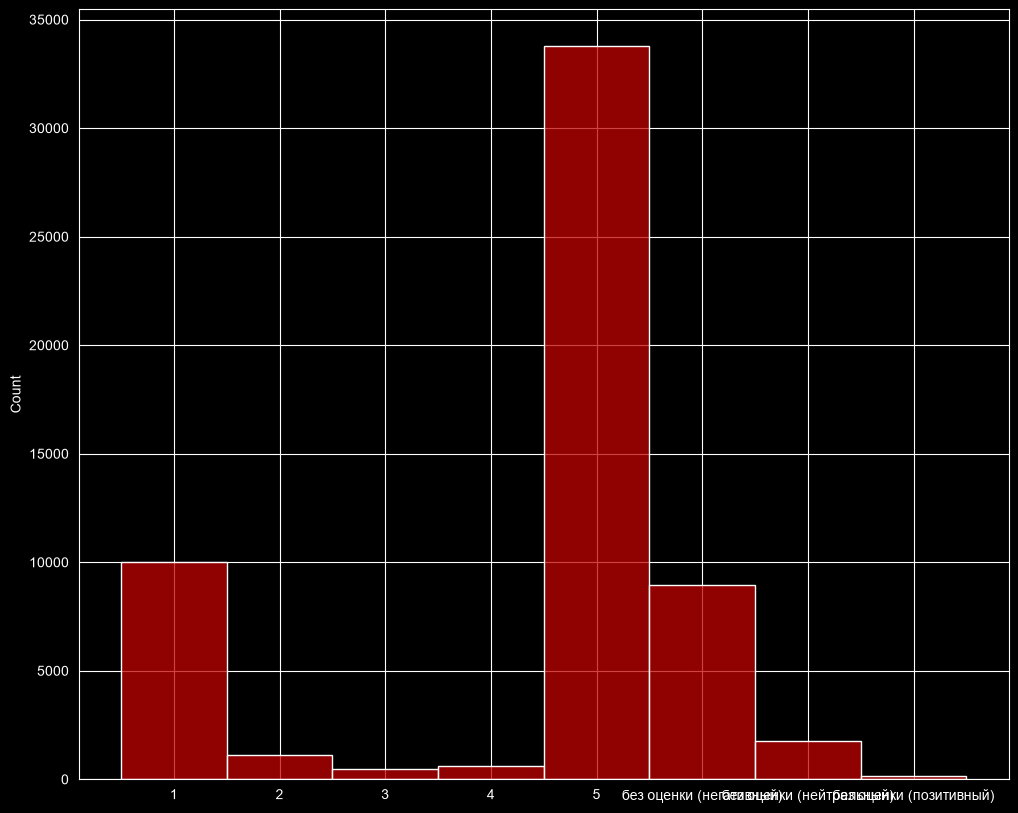

In [119]:
plt.figure(figsize=(12, 10))
sns.histplot(data=df, x=sorted(df['review_mark']), color='#C10404')
plt.show()

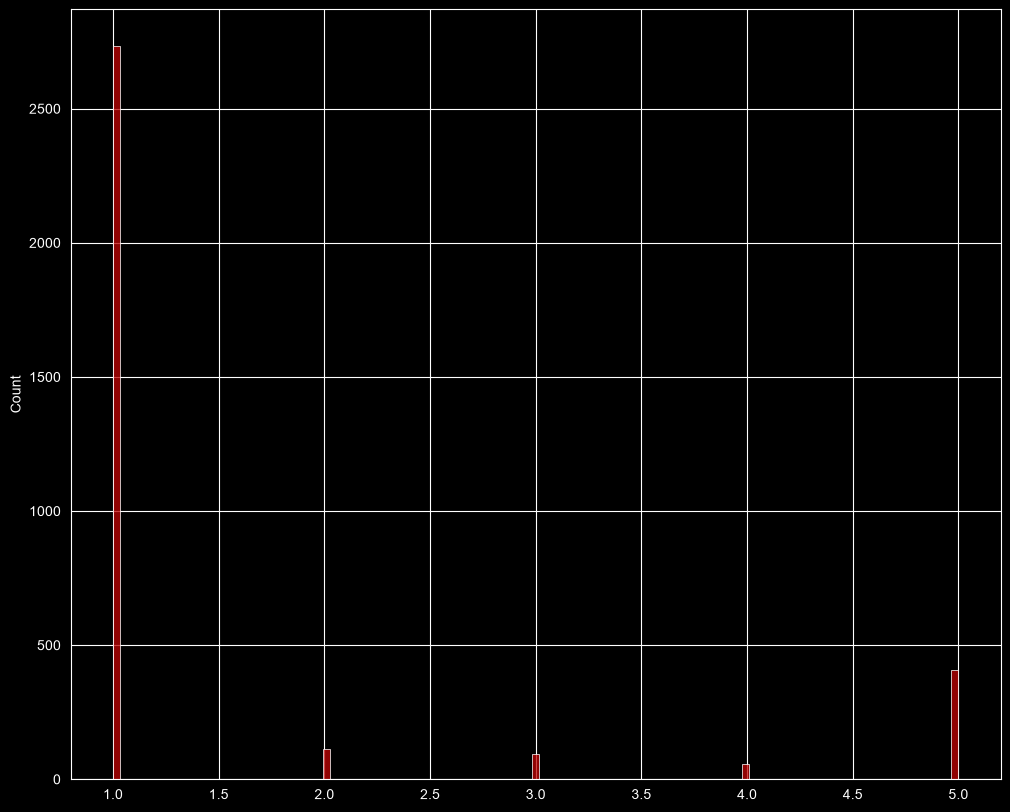

In [120]:
plt.figure(figsize=(12, 10))
sns.histplot(data=df, x=sorted(df['csat_score']), color='#C10404')
plt.show()

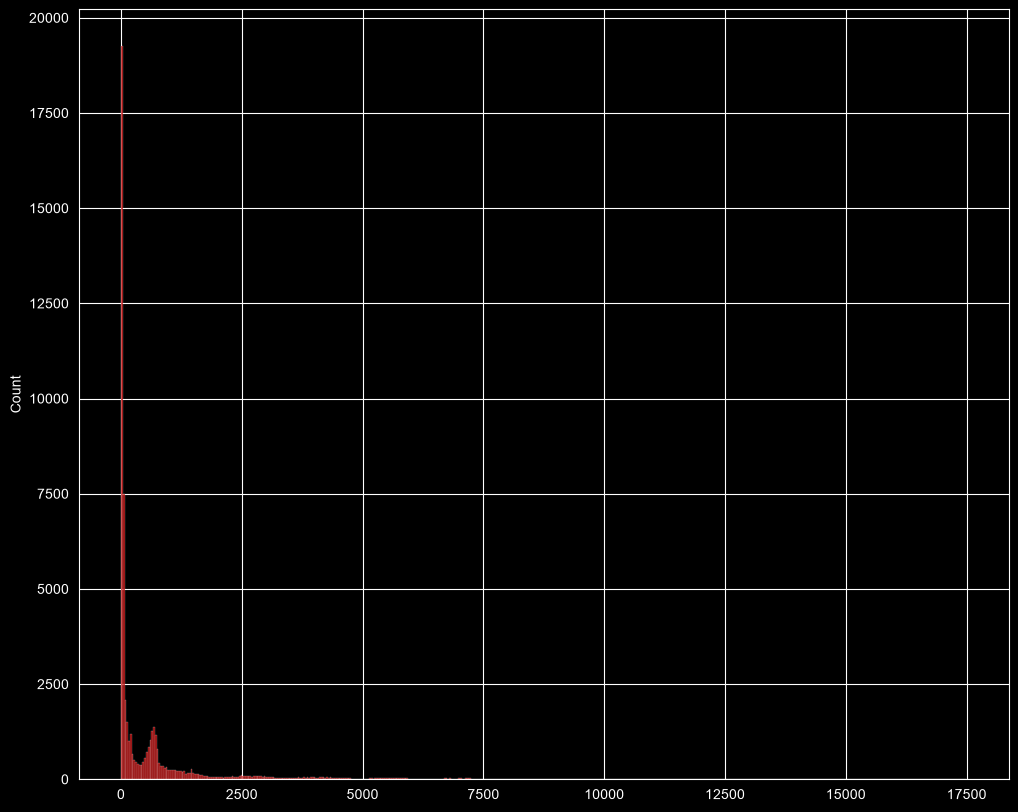

In [121]:
plt.figure(figsize=(12, 10))
sns.histplot(data=df_clean, x=sorted(df_clean['diff_dttm']), color='#C10404')
plt.show()

EDA

In [63]:
cols = ['segment_name', 'gender_cd', 'age_segment', 'review_source', 'review_emotion']
for col in cols:
    freq = df[col].value_counts(dropna=False)
    percent = df[col].value_counts(dropna=False, normalize=True) * 100
    table = pd.DataFrame({'Количество': freq, 'Процент': percent.round(2)})
    print(table)

                       Количество  Процент
segment_name                              
Доходные                    22157    39.00
Малодоходные                15964    28.10
Unknown                     13212    23.25
Высокодоходные без ПМ        2418     4.26
Высокодоходные с ПМ          1686     2.97
Защищенные                   1383     2.43
           Количество  Процент
gender_cd                     
M               33364    58.72
F               23131    40.71
NaN               325     0.57
              Количество  Процент
age_segment                      
Взрослые           25088    44.15
Unknown            10767    18.95
Молодежь            9525    16.76
Сеньоры             5869    10.33
Подростки           2964     5.22
Не определен        2582     4.54
Дети                  25     0.04
                Количество  Процент
review_source                      
banki.ru             48224    84.87
sravni.ru             3541     6.23
пульс                 1280     2.25
otzovik        

In [64]:
df['review_mark_num'] = pd.to_numeric(df['review_mark'], errors='coerce')
df['review_mark_num'].describe()

count    45937.000000
mean         4.024925
std          1.672758
min          1.000000
25%          3.000000
50%          5.000000
75%          5.000000
max          5.000000
Name: review_mark_num, dtype: float64

In [65]:
pivot1 = pd.pivot_table(df, values='review_mark_num', index='segment_name', aggfunc='mean')
pivot1

,review_mark_num
segment_name,
Unknown,4.354001
Высокодоходные без ПМ,4.290073
Высокодоходные с ПМ,4.513939
Доходные,3.896387
Защищенные,3.703140
Малодоходные,3.816064


In [66]:
pivot2 = pd.pivot_table(df, values='review_mark_num', index='age_segment', aggfunc='mean')
pivot2

,review_mark_num
age_segment,
Unknown,4.499606
Взрослые,3.896329
Дети,3.882353
Молодежь,3.805406
Не определен,3.904950
Подростки,4.091832
Сеньоры,3.893238


In [67]:
cross_pct = pd.crosstab(df['gender_cd'], df['review_emotion'], normalize='index') * 100
cross_pct

review_emotion,Негативный,Позитивный
gender_cd,,
F,34.252734,65.747266
M,42.815610,57.184390


<Axes: xlabel='diff_dttm'>

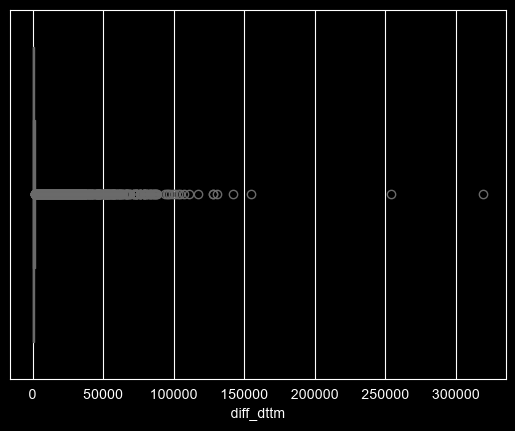

In [68]:
sns.boxplot(x=df_clean['diff_dttm'])

<Axes: xlabel='review_mark_num'>

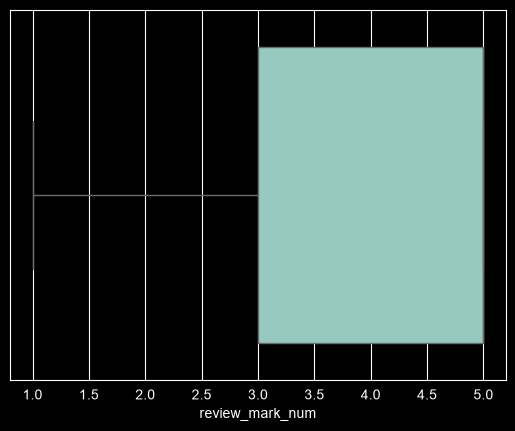

In [69]:
sns.boxplot(x=df['review_mark_num'])

In [70]:
p99 = df_clean['diff_dttm'].quantile(0.99)
df_clean = df_clean[df_clean['diff_dttm'] <= p99]

H1

In [71]:
subs_mark = df.groupby('subscription_important_flg')['review_mark_num'].agg('mean')
subs_mark

subscription_important_flg
0.0        3.885170
1.0        4.513243
Unknown    4.354001
Name: review_mark_num, dtype: float64

In [72]:
segment_mark = df.groupby('segment_name')['review_mark_num'].agg('mean')
segment_mark

segment_name
Unknown                  4.354001
Высокодоходные без ПМ    4.290073
Высокодоходные с ПМ      4.513939
Доходные                 3.896387
Защищенные               3.703140
Малодоходные             3.816064
Name: review_mark_num, dtype: float64

In [127]:
time_subs = df_clean.groupby('subscription_important_flg')['diff_dttm'].agg('median')
time_subs

subscription_important_flg
0.0    107.593350
1.0     58.311183
Name: diff_dttm, dtype: float64

In [74]:
segment_time = df_clean.groupby('segment_name')['diff_dttm'].agg('median')
segment_time

segment_name
Высокодоходные без ПМ     48.716667
Высокодоходные с ПМ       58.311183
Доходные                 107.304233
Защищенные               140.166550
Малодоходные             122.744433
Name: diff_dttm, dtype: float64

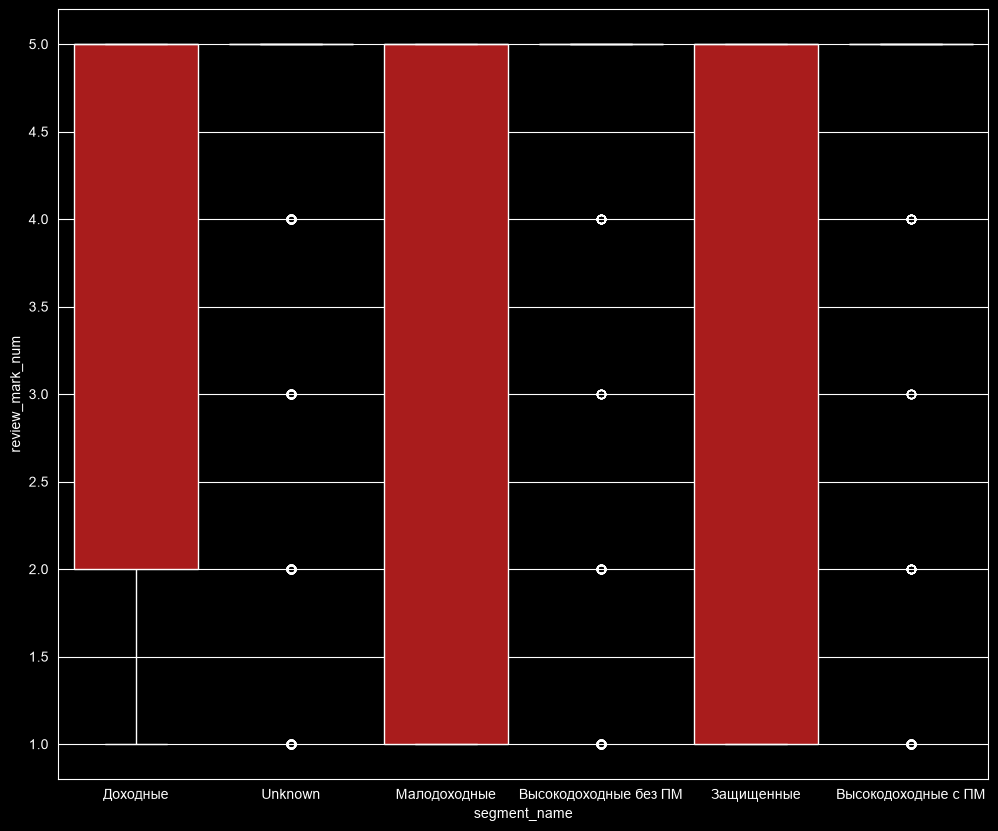

In [126]:
plt.figure(figsize=(12, 10))
sns.boxplot(data=df, x='segment_name', y='review_mark_num', color='#C10404', linecolor='white')
plt.show()

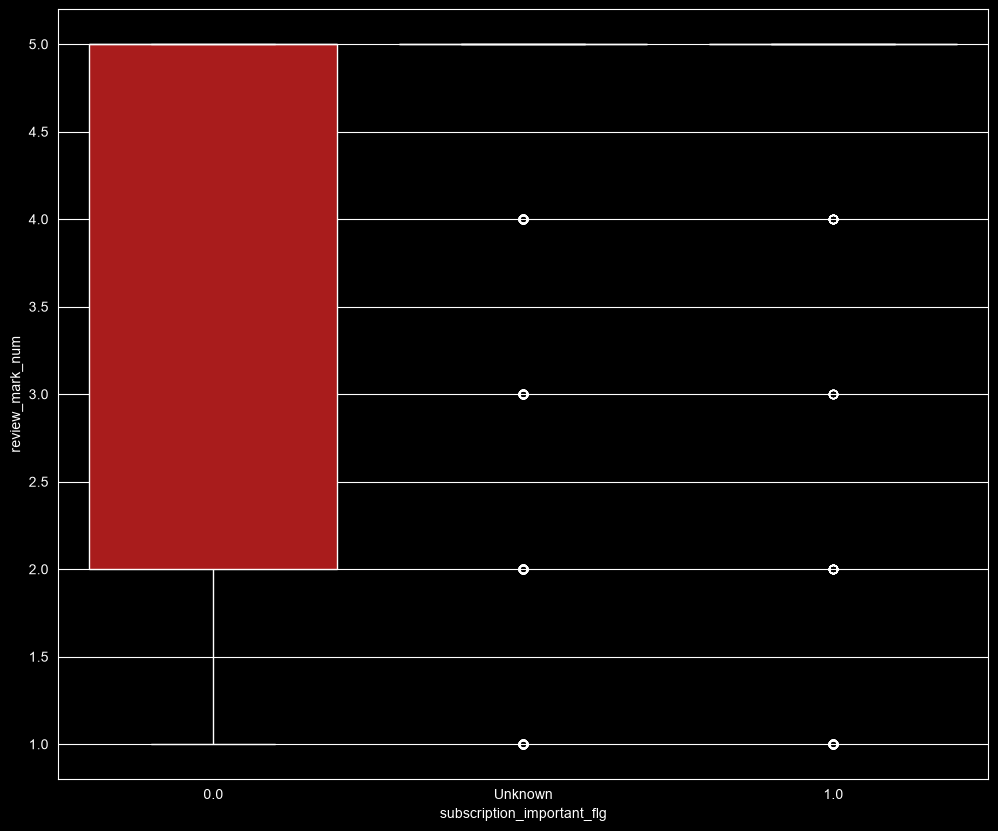

In [128]:
plt.figure(figsize=(12, 10))
sns.boxplot(data=df, x='subscription_important_flg', y='review_mark_num', color='#C10404', linecolor='white')
plt.show()

In [77]:
pd.pivot_table(df, values='solution_flg', index='segment_name', aggfunc='count')

,solution_flg
segment_name,
Unknown,13212
Высокодоходные без ПМ,2418
Высокодоходные с ПМ,1686
Доходные,22157
Защищенные,1383
Малодоходные,15964


In [122]:
group0 = df[df['subscription_important_flg'] == 0]['review_mark_num'].dropna()
group1 = df[df['subscription_important_flg'] == 1]['review_mark_num'].dropna()
t_stat, p_val = ttest_ind(group0, group1)
print(f't={t_stat}, p={p_val}')
if p_val < 0.05:
    print(True)

t=-13.287282406308622, p=3.4539108229809462e-40
True


H2


In [79]:
df['is_positive'] = df['review_mark_num'] >= 4

In [80]:
h2_table = df.groupby('new_flg')['is_positive'].mean() * 100
h2_table

new_flg
0.0        56.443069
1.0        46.390658
Unknown    74.598850
Name: is_positive, dtype: float64

In [81]:
neg_df = df[df['review_mark_num'] < 4]
top_themes_new = neg_df[neg_df['new_flg'] == 1]['review_theme'].value_counts().head(5)
top_themes_old = neg_df[neg_df['new_flg'] == 0]['review_theme'].value_counts().head(5)
print(top_themes_new)
print(top_themes_old)

review_theme
карты                            49
акции                            34
погашение кредитных продуктов    33
Не определено                    28
тарифы и условия                 26
Name: count, dtype: int64
review_theme
тарифы и условия                 1255
карты                            1231
погашение кредитных продуктов     904
кэшбек                            790
платежи, переводы и операции      715
Name: count, dtype: int64


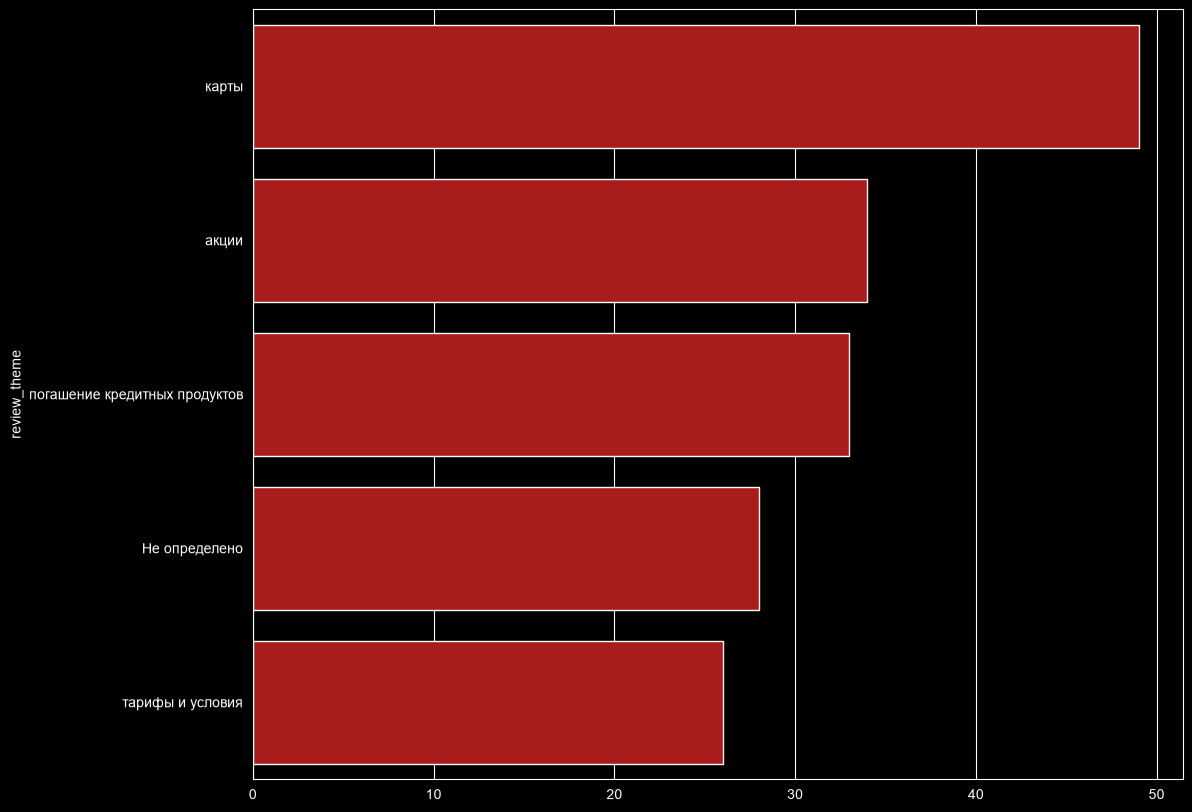

In [129]:
plt.figure(figsize=(12, 10))
sns.barplot(x=top_themes_new.values, y=top_themes_new.index, color='#C10404')
plt.show()

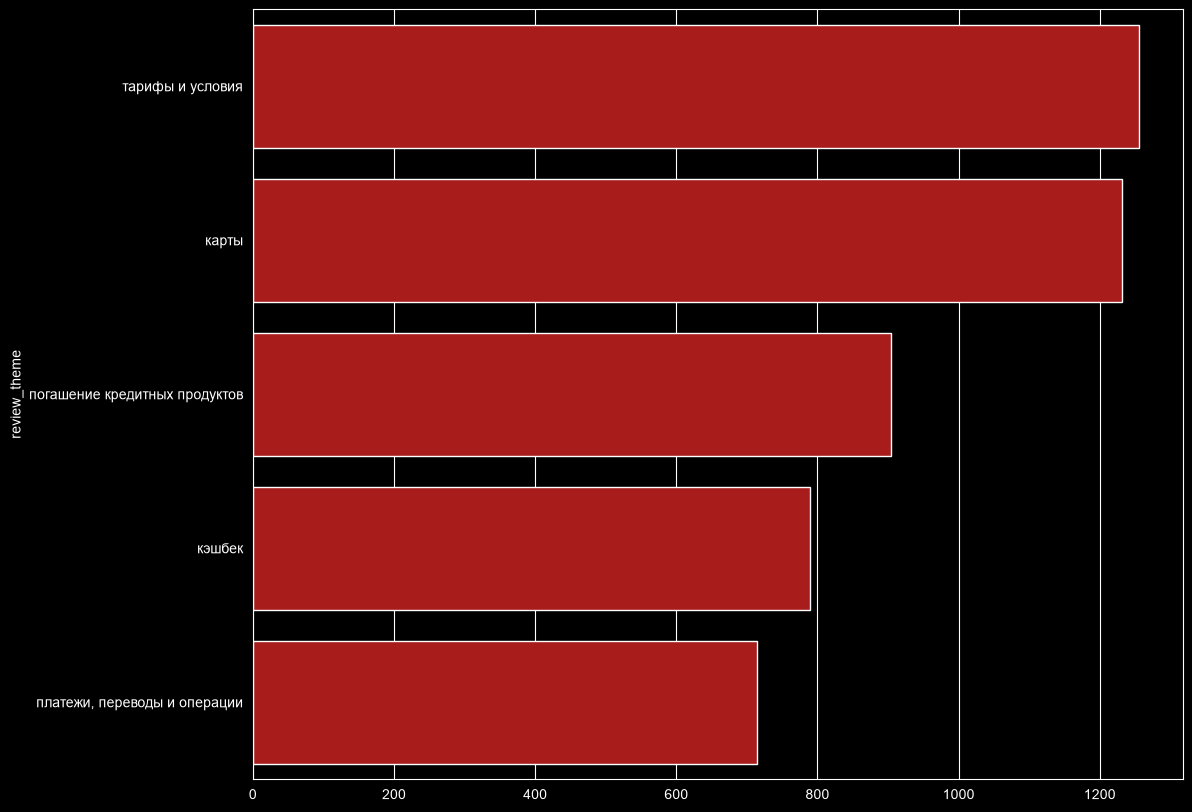

In [130]:
plt.figure(figsize=(12, 10))
sns.barplot(x=top_themes_old.values, y=top_themes_old.index, color='#C10404')
plt.show()

In [84]:
contingency = pd.crosstab(df['new_flg'], df['is_positive'])
chi2, p, dof, expected = chi2_contingency(contingency)
print(f'chi2={chi2}, p={p}')

chi2=1471.259597452268, p=0.0


H3

In [85]:
service_words = ['оператор', 'общение', 'помощь', 'спасибо', 'грубость', 'менеджер', 'поддержка']
finance_words = ['процент', 'ставка', 'комиссия', 'доходность', 'инвестиции', 'вклад', 'кредит']

In [86]:
def count_words(text, word_list):
    if not isinstance(text, str):
        return 0
    text_lower = text.lower()
    return sum(text_lower.count(word) for word in word_list)

In [87]:
df['service_count'] = df['review_text'].apply(lambda x: count_words(x, service_words))
df['finance_count'] = df['review_text'].apply(lambda x: count_words(x, finance_words))


In [88]:
h3_service = df.groupby('gender_cd')['service_count'].mean()
h3_finance = df.groupby('gender_cd')['finance_count'].mean()
print(h3_service)
print(h3_finance)

gender_cd
F    1.015261
M    0.843784
Name: service_count, dtype: float64
gender_cd
F    0.42804
M    0.44518
Name: finance_count, dtype: float64


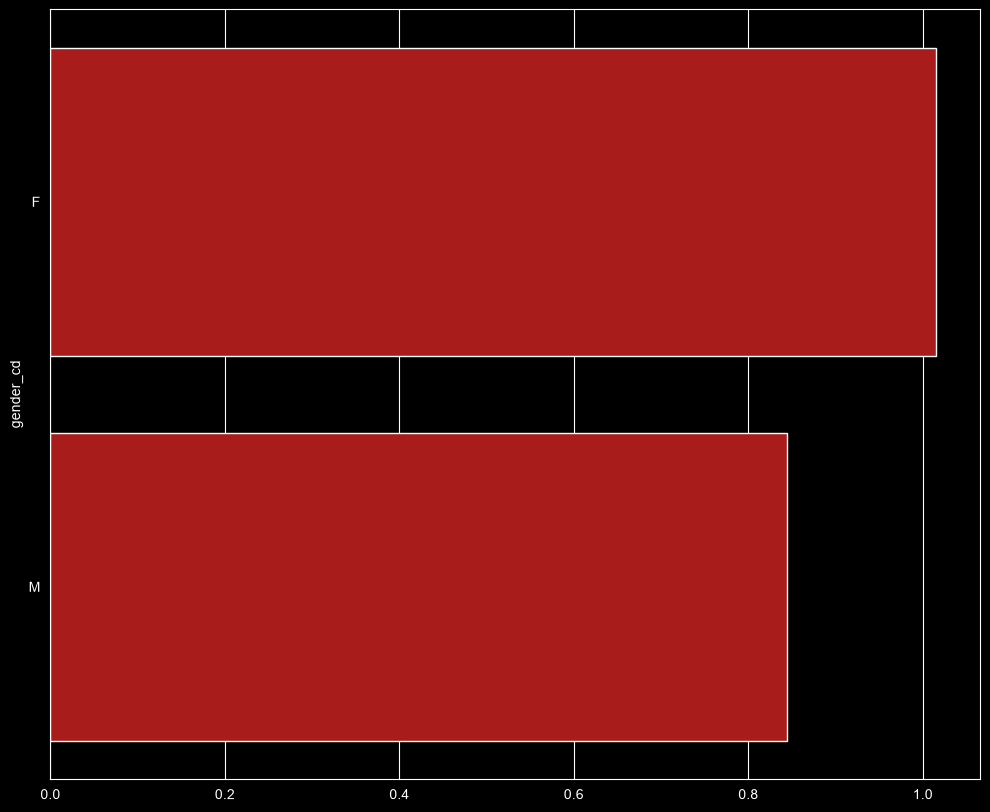

In [131]:
plt.figure(figsize=(12, 10))
sns.barplot(x=h3_service.values, y=h3_service.index, color='#C10404')
plt.show()

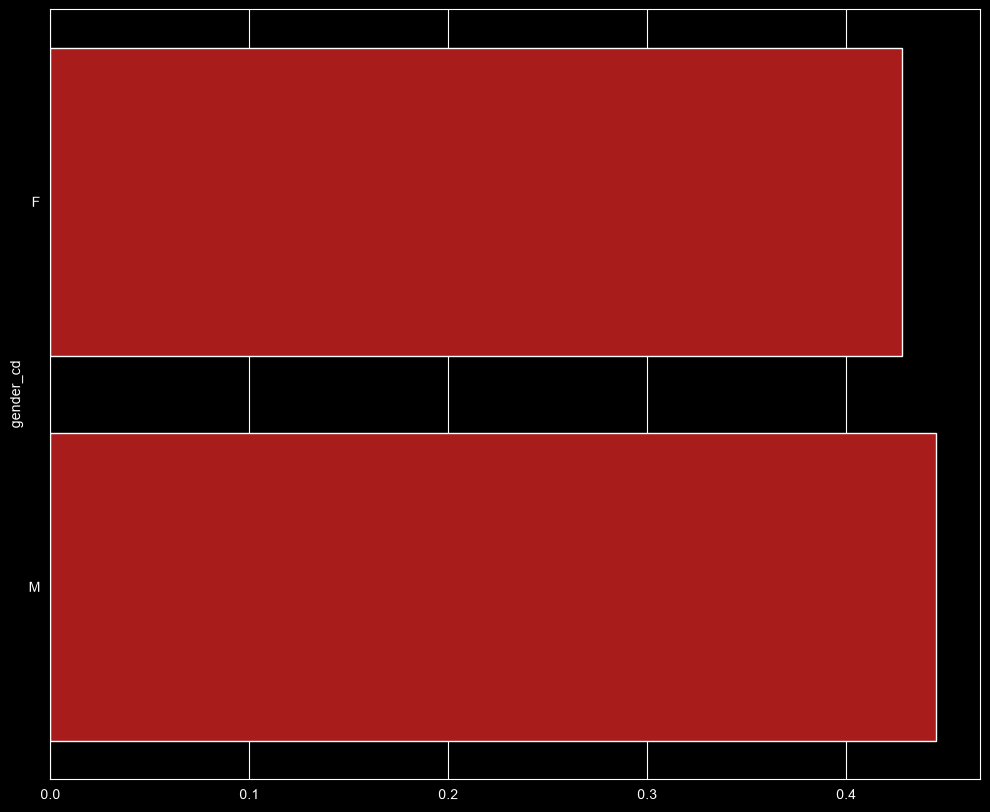

In [132]:
plt.figure(figsize=(12, 10))
sns.barplot(x=h3_finance.values, y=h3_finance.index, color='#C10404')
plt.show()

In [91]:
service_m = df[df['gender_cd'] == 'M']['service_count']
service_f = df[df['gender_cd'] == 'F']['service_count']
t_stat, p_val = ttest_ind(service_m, service_f, equal_var=False)
print(f"Сервисные слова: t={t_stat:.3f}, p={p_val:.5f}")

Сервисные слова: t=-17.169, p=0.00000


In [92]:
finance_m = df[df['gender_cd'] == 'M']['finance_count']
finance_f = df[df['gender_cd'] == 'F']['finance_count']
t_stat, p_val = ttest_ind(finance_m, finance_f)
print(f"t={t_stat}, p={p_val}")

t=1.586126837173242, p=0.1127161370037924


H4

In [93]:
df['is_negative'] = df['review_emotion'] == 'Негативный'

In [94]:
h4_table = pd.crosstab(index=df['review_source'], columns=df['segment_name'], values=df['is_negative'], aggfunc='mean') * 100
h4_table


segment_name,Unknown,Высокодоходные без ПМ,Высокодоходные с ПМ,Доходные,Защищенные,Малодоходные
review_source,,,,,,
appstore,NaN,NaN,NaN,NaN,NaN,100.000000
asn,4.452055,NaN,NaN,NaN,NaN,0.000000
banki.ru,24.248552,32.874251,16.451149,38.588859,46.475410,42.904383
instagramm,NaN,NaN,NaN,50.000000,NaN,NaN
irecommend,50.000000,100.000000,NaN,76.470588,NaN,100.000000
otzovik,67.721519,62.500000,35.294118,76.842105,76.666667,80.645161
sravni.ru,18.875502,4.054054,11.428571,22.379603,28.070175,35.135135
twitter,100.000000,NaN,NaN,100.000000,100.000000,100.000000
vc,100.000000,100.000000,100.000000,99.082569,100.000000,100.000000


In [95]:
sub_df = df[df['segment_name'] == 'Доходные']
tab = pd.crosstab(sub_df['review_source'], sub_df['is_negative'])
chi2_sub, p_sub, _, _ = chi2_contingency(tab)
print(f"H4 (Доходные): chi2={chi2_sub:.3f}, p={p_sub:.5f}")

H4 (Доходные): chi2=2911.509, p=0.00000


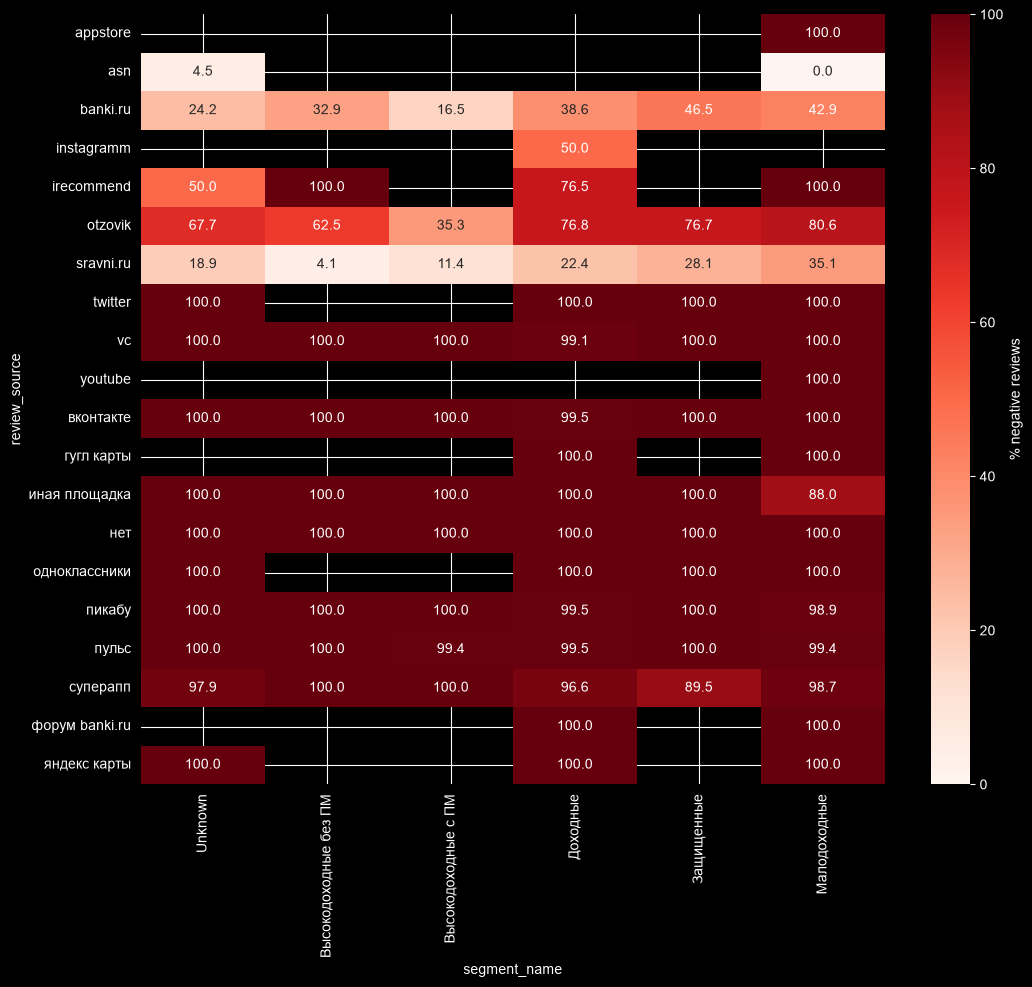

In [133]:
plt.figure(figsize=(12, 10))
sns.heatmap(data=h4_table, annot=True, fmt='.1f', cmap='Reds', cbar_kws={'label': '% negative reviews'})
plt.show()

Сводная таблица по сегментам и параметрам

In [134]:
df['solution_flg_num'] = df['solution_flg'].map({'1': 1, '0': 0}).fillna(0).astype(float)
agg_df = df.groupby('segment_name').agg(
    count=('segment_name', 'count'),
    mean_mark=('review_mark_num', 'mean'),
    pct_negative=('is_negative', 'mean'),
)
agg_clean = df_clean.groupby('segment_name')['diff_dttm'].median()
summary = agg_df.join(agg_clean)
summary.columns = ['Количество', 'Средняя оценка', 'Доля негатива', 'Медианное время (мин)']
summary = summary.round(2)
summary = summary.sort_values('Доля негатива', ascending=False)
print(summary)


                       Количество  Средняя оценка  Доля негатива  \
segment_name                                                       
Защищенные                   1383            3.70           0.49   
Малодоходные                15964            3.82           0.47   
Доходные                    22157            3.90           0.44   
Высокодоходные без ПМ        2418            4.29           0.30   
Высокодоходные с ПМ          1686            4.51           0.27   
Unknown                     13212            4.35           0.25   

                       Медианное время (мин)  
segment_name                                  
Защищенные                            140.17  
Малодоходные                          122.74  
Доходные                              107.30  
Высокодоходные без ПМ                  48.72  
Высокодоходные с ПМ                    58.31  
Unknown                                  NaN  


In [112]:
print(df['solution_flg'].value_counts())

solution_flg
не указано         43661
проблема решена    13159
Name: count, dtype: int64
